<a href="https://colab.research.google.com/github/Rahmi1635/MachineLearningExamples/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


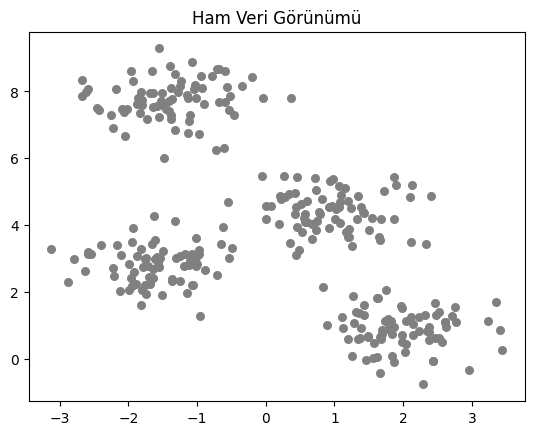

In [8]:
X,y=make_blobs(n_samples=300,centers=4,cluster_std=0.60,random_state=0)

plt.scatter(X[:,0],X[:,1],s=30,color="gray")
plt.title("Ham Veri Görünümü")
plt.show()

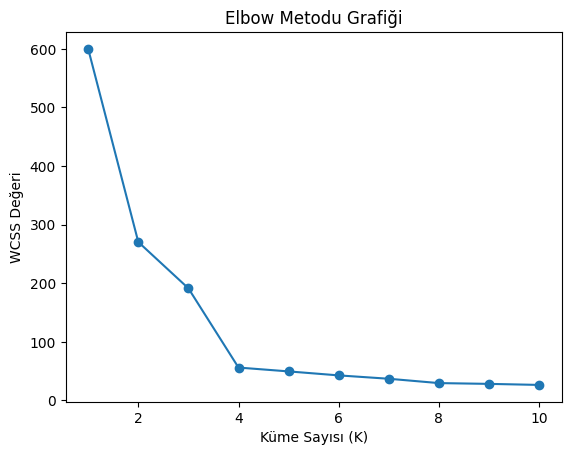

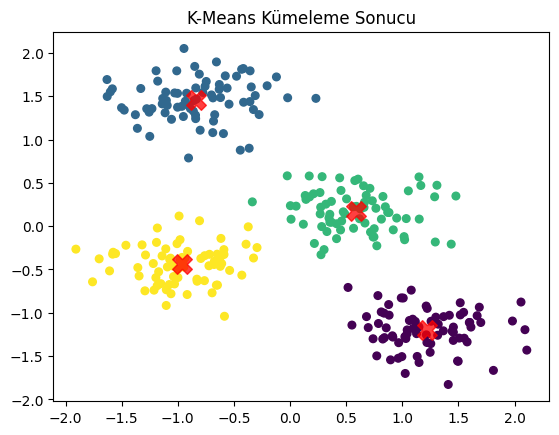

In [28]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

wcss = [] # Hata paylarını saklayacağımız liste


for i in range(1, 11):
    kmeans_elbow = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_elbow.fit(X_scaled)
    # inertia_ : Algoritmanın hesapladığı WCSS (hata payı) değeridir
    wcss.append(kmeans_elbow.inertia_)

# Sonuçları grafik üzerine dökerek "dirseği" görelim
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Metodu Grafiği')
plt.xlabel('Küme Sayısı (K)')
plt.ylabel('WCSS Değeri')
plt.show()

kmeans=KMeans(n_clusters=4,init="k-means++",random_state=42)
y_kmeans=kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y_kmeans,s=30,cmap="viridis")
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title("K-Means Kümeleme Sonucu")
plt.show()

In [31]:
score=silhouette_score(X_scaled,y_kmeans)
print(f"Modelin Skoru : ,{score:.2f}")

Modelin Skoru : ,0.66
